Title: Bias_analysis.ipynb

Purpose: Look at the distribution of the different input and output variables form all models to recognise potential biases

Author: Onno Nennecke on 17.04.2025 Modified: 06.05.2025


In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import scipy.ndimage as ndimage
import seaborn as sns
import os
import glob

In [3]:
path = '/climca/people/onennecke/model_output/var_means_masked/winter_data/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))
# files = files[:60] + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

# Rename variables without _masked
ts_datasets = ts_datasets.rename({
    'sfcWind_masked': 'sfcWind',
    'rsds_masked': 'rsds',
    'tas_masked': 'tas',
    'tasmax_masked': 'tasmax'
})

ts_datasets

<xarray.Dataset> Size: 6MB
Dimensions:        (ESM_run: 100, time: 1820)
Coordinates:
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    winter_year    (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    day_of_winter  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    winter_season  (time) <U8 58kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    sfcWind        (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    rsds           (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tas            (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tasmax         (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>

## Bias analysis

#### Mean per day of winter

In [4]:
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(ts_datasets['ESM'].values):
    filtered_dataset = ts_datasets.where(ts_datasets['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('day_of_winter').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'day_of_winter': mean_by_day['day_of_winter'].values,
        # 'temp': mean_by_day['temp'].values,
        # 'demand': mean_by_day['demand'].values,
        # 'demand_weekly': mean_by_day['demand_weekly'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds' : mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
        # 'wind_off_prod': mean_by_day['wind_off_prod'].values,
        # 'wind_on_prod': mean_by_day['wind_on_prod'].values,
        # 'solar_prod': mean_by_day['solar_prod'].values,
        # 'total_prod': mean_by_day['total_prod'].values,
        # 'netto': mean_by_day['Netto'].values,
        # 'Residual_load': mean_by_day['Residual_load'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df

,day_of_winter,sfcWind,rsds,tas,tasmax,ESM
0,1,1.794595,63.139902,7.307359,9.371079,ACCESS-CM2
1,2,1.836769,64.894875,7.180770,9.111866,ACCESS-CM2
2,3,1.750496,63.955849,6.773843,8.664421,ACCESS-CM2
3,4,1.601308,63.027921,6.592814,8.404575,ACCESS-CM2
4,5,1.647209,60.050305,6.390651,8.118308,ACCESS-CM2
...,...,...,...,...,...,...
1997,178,2.424394,76.977864,2.898546,4.566010,UKESM1-0-LL
1998,179,2.418104,76.474418,2.995985,4.630608,UKESM1-0-LL
1999,180,2.385793,76.292733,3.072448,4.696163,UKESM1-0-LL
2000,181,2.290463,80.911555,3.143200,4.853572,UKESM1-0-LL


In [5]:
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

# variables = [
#     'sfcWind', 'rsds', 'tas', 'tasmax', 'temp', 'demand',
#     'wind_off_prod', 'wind_on_prod', 'solar_prod',
#     'total_prod', 'Residual_load'
# ]

variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax'
]

# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 1820).astype(int)
esm_label_map = {esm: f"{esm} (n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)

#### Combined plot

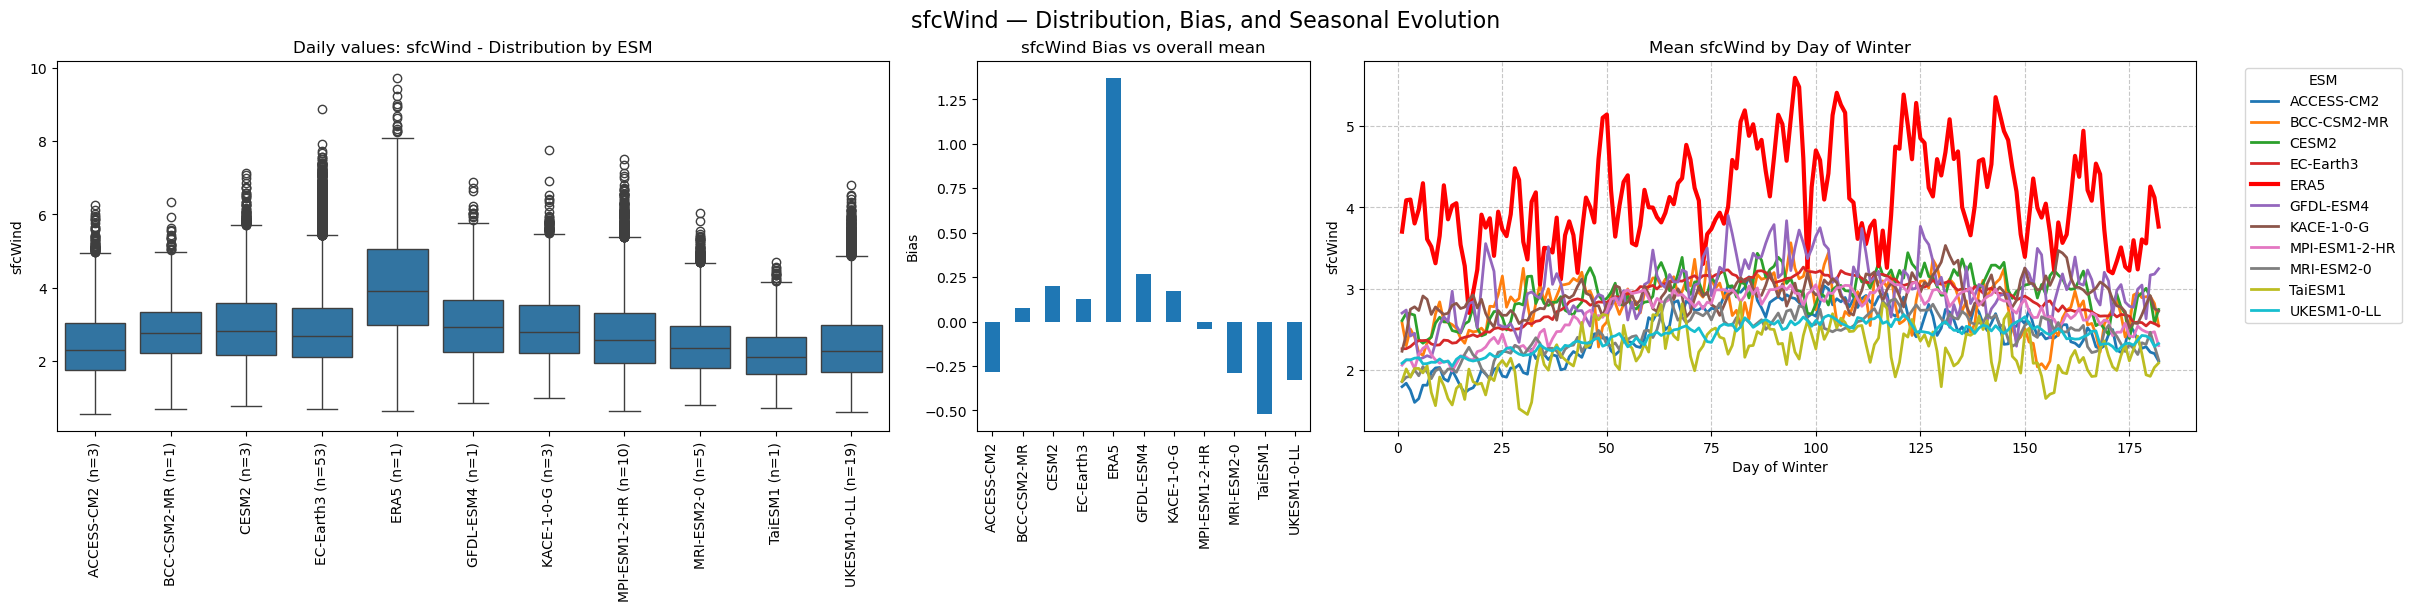

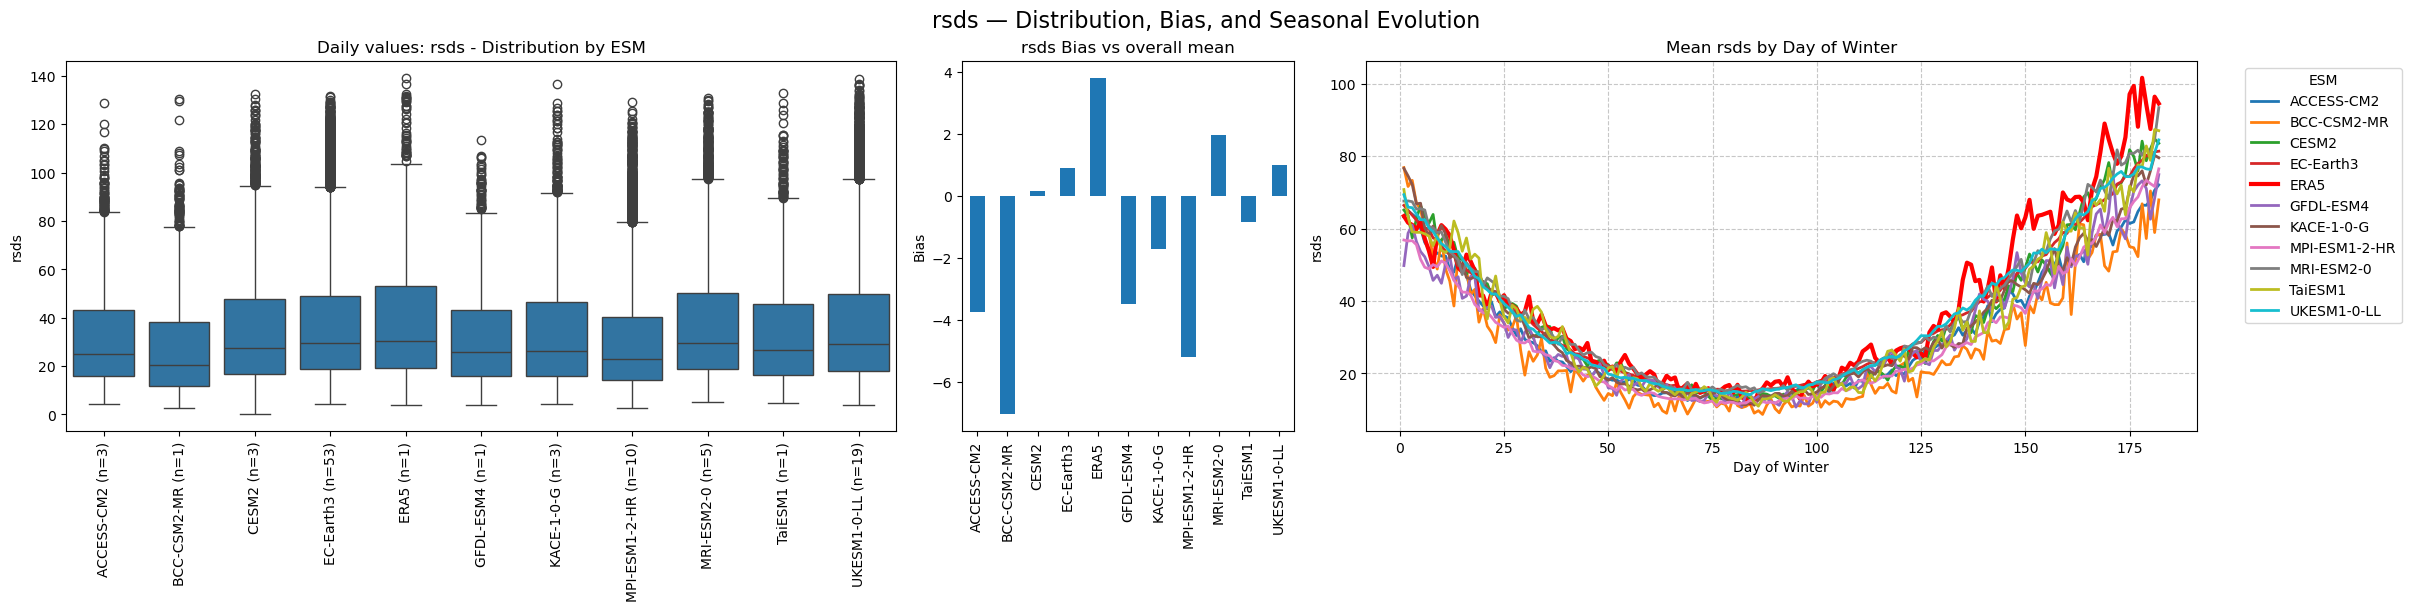

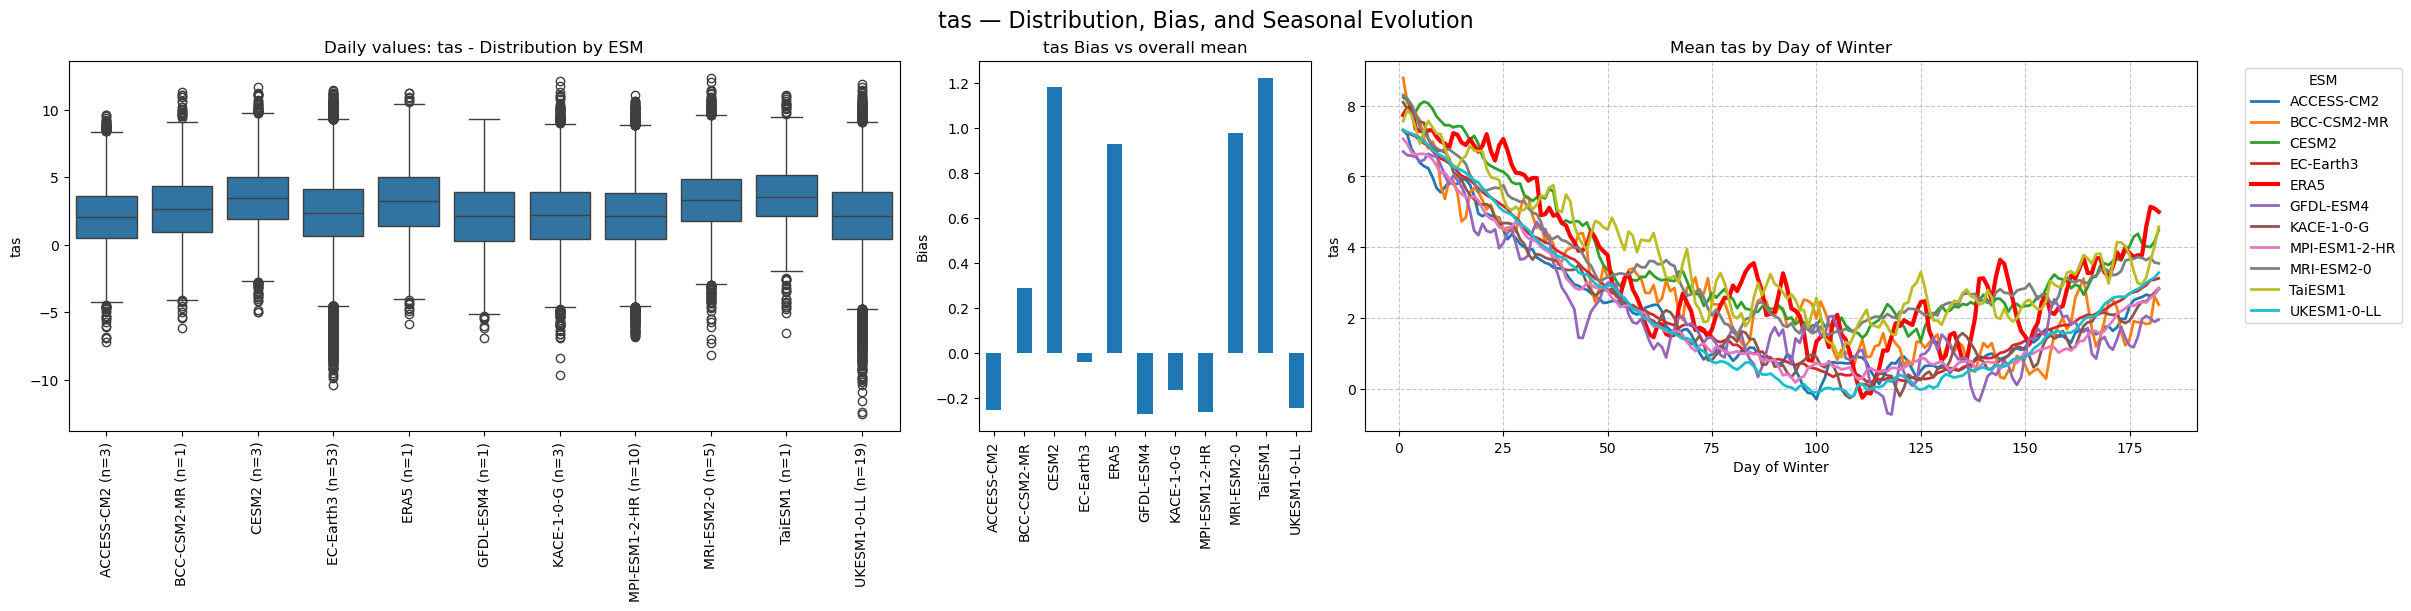

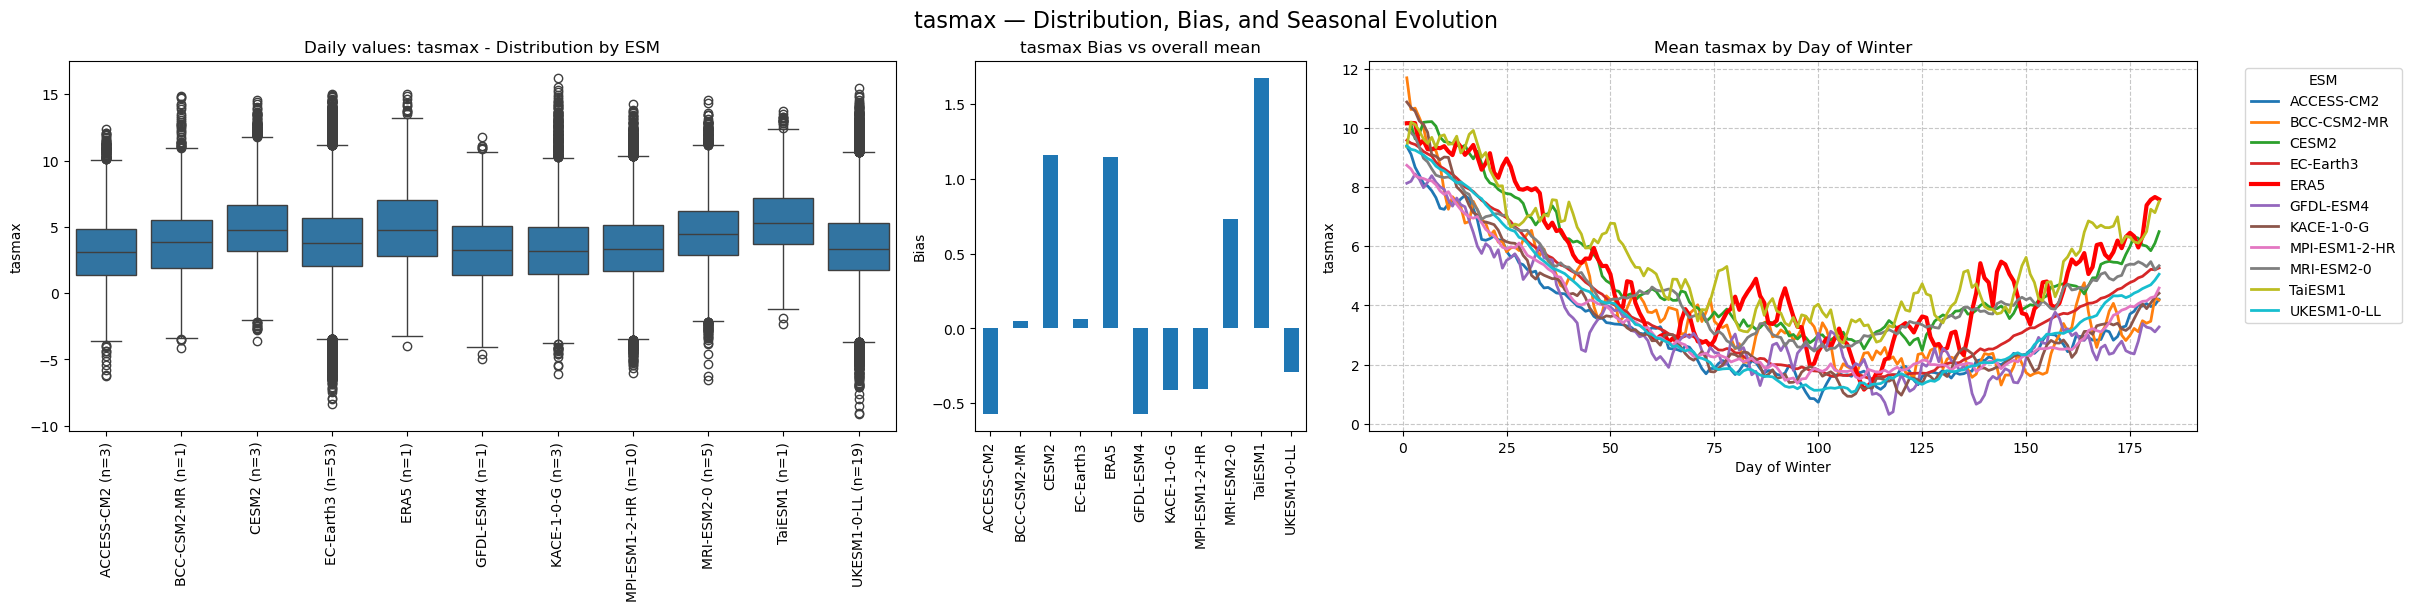

In [7]:

# Loop over variables and plot boxplot, bias, and seasonal lineplot
for var in variables:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 6),
        gridspec_kw={'width_ratios': [3, 1.2, 3]},
        constrained_layout=True
    )

    # 1. Boxplot (left)
    sns.boxplot(data=df, x='ESM_label', y=var, ax=axes[0])
    axes[0].set_title(f'Daily values: {var} - Distribution by ESM')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xlabel('')
    axes[0].set_ylabel(var)

    # 2. Bias barplot (middle)

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    bias.to_series().plot.bar(ax=axes[1])
    axes[1].set_title(f'{var} Bias vs overall mean')
    axes[1].set_ylabel('Bias')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=90)


    # 3. Line plot (right)

    if var in final_df.columns:
        for esm, group in final_df.groupby('ESM'):
            if esm == 'ERA5':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=3, label='ERA5')
            else:
                axes[2].plot(group['day_of_winter'], group[var], linewidth=2, label=esm)

        axes[2].set_title(f'Mean {var} by Day of Winter')
        axes[2].set_xlabel('Day of Winter')
        axes[2].set_ylabel(var)
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')
    else:
        axes[2].text(0.5, 0.5, f'{var} not in final_df', ha='center', va='center')
        axes[2].set_axis_off()


    # Title
    plt.suptitle(f'{var} — Distribution, Bias, and Seasonal Evolution', fontsize=16)
    plt.show()


#### ECDFs

Text(0.5, 1.0, 'ECDFs of sfcWind per ESM')

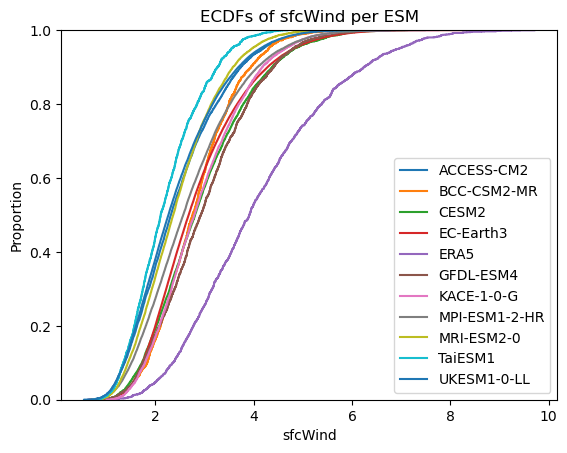

In [8]:
tas_df = ts_datasets['sfcWind'].to_dataframe().reset_index()
for model in tas_df['ESM'].unique():
    subset = tas_df[tas_df['ESM'] == model]
    sns.ecdfplot(subset['sfcWind'], label=model)
plt.legend()
plt.title("ECDFs of sfcWind per ESM")

#### Mean per day of winter single plots

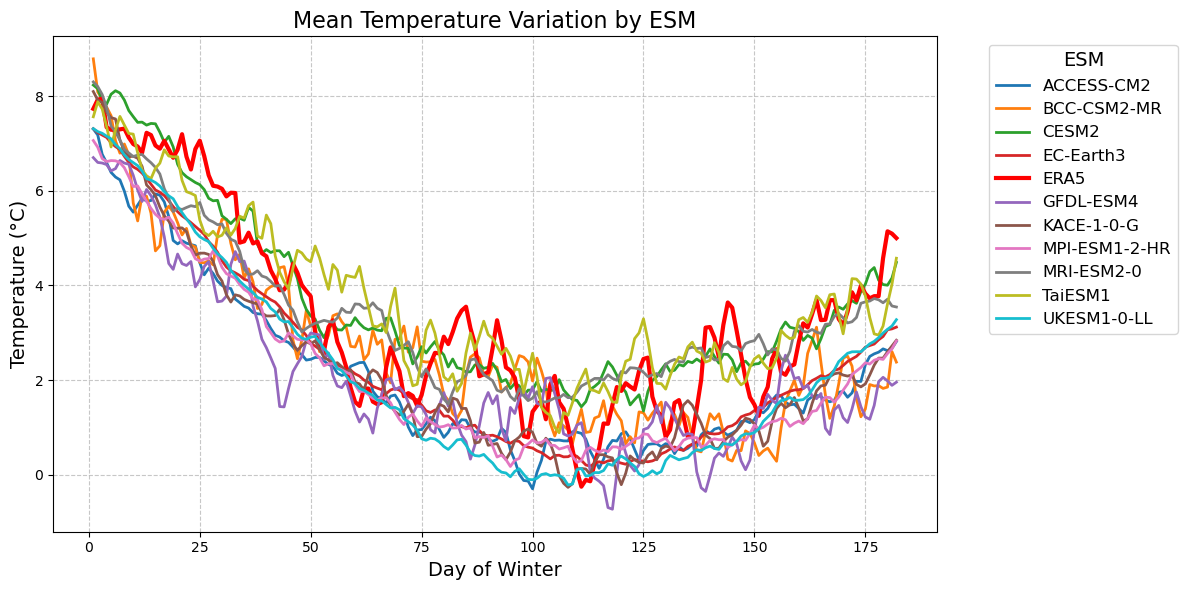

In [10]:
# Plot the data
plt.figure(figsize=(12, 6))
for esm, group in final_df.groupby('ESM'):
    if esm == 'ERA5':
        plt.plot(group['day_of_winter'], group['tas'], color='red', linewidth=3, label='ERA5')
        continue
    plt.plot(group['day_of_winter'], group['tas'], label=esm, linewidth=2)

# Add title and labels
plt.title('Mean Temperature Variation by ESM', fontsize=16)
plt.xlabel('Day of Winter', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)

# Customize legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title='ESM', title_fontsize=14)

# Add grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()



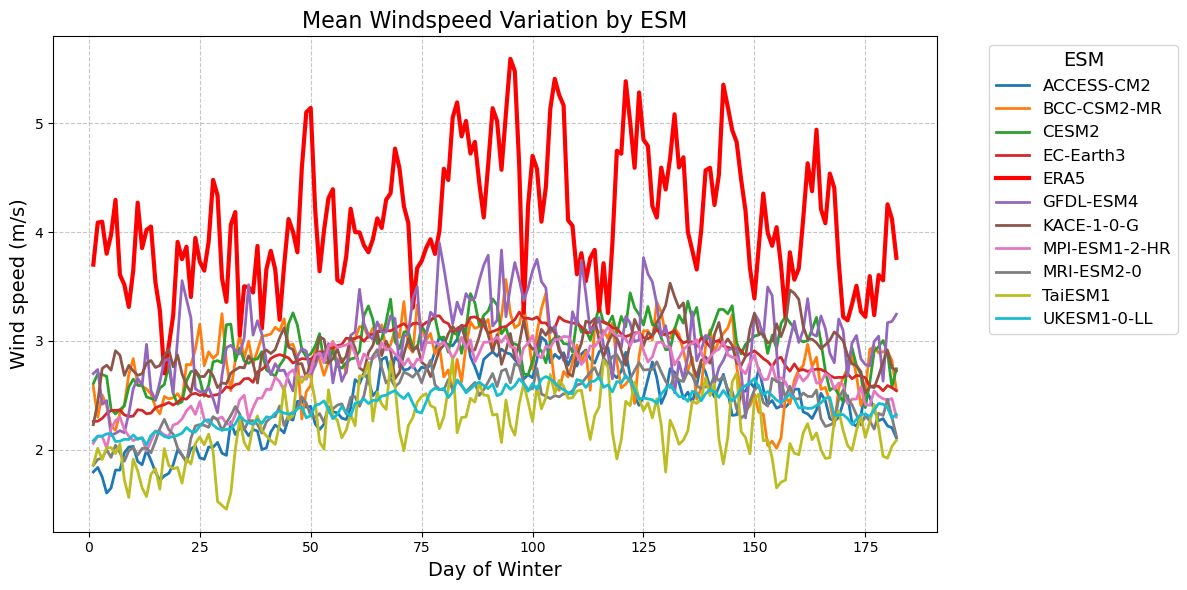

In [11]:
# Plot the data
plt.figure(figsize=(12, 6))
for esm, group in final_df.groupby('ESM'):
    if esm == 'ERA5':
        plt.plot(group['day_of_winter'], group['sfcWind'], color='red', linewidth=3, label='ERA5')
        continue
    plt.plot(group['day_of_winter'], group['sfcWind'], label=esm, linewidth=2)
# for esm, group in final_df.groupby('ESM'):
#     plt.plot(group['day_of_winter'], group['sfcWind'], label=esm, linewidth=2)

# Add title and labels
plt.title('Mean Windspeed Variation by ESM', fontsize=16)
plt.xlabel('Day of Winter', fontsize=14)
plt.ylabel('Wind speed (m/s)', fontsize=14)

# Customize legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title='ESM', title_fontsize=14)

# Add grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()



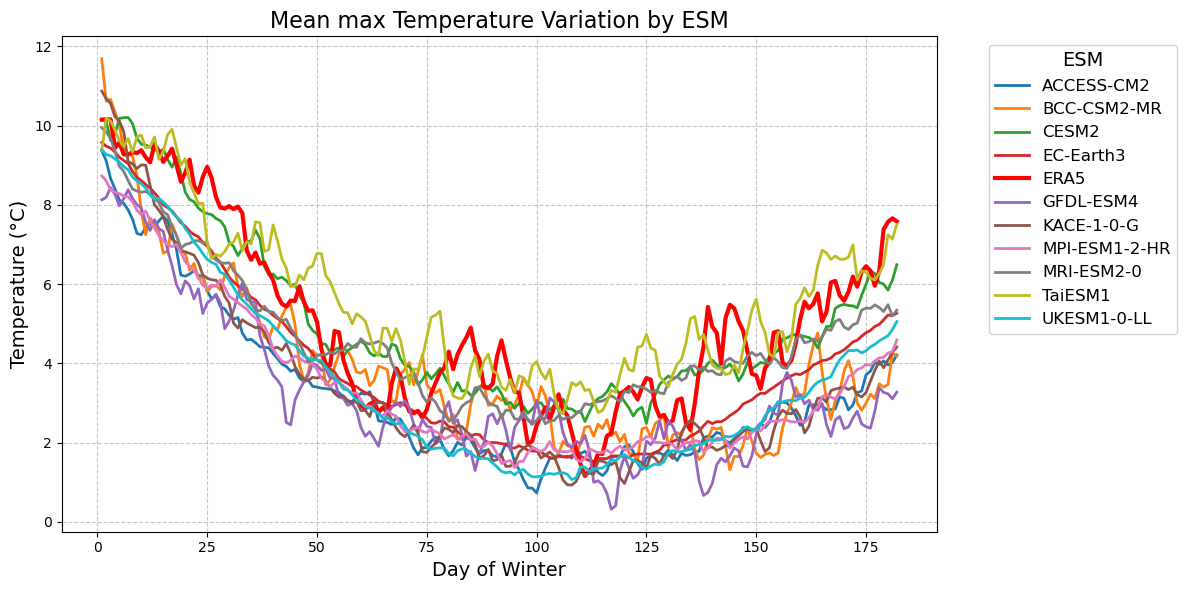

In [12]:
# Plot the data
plt.figure(figsize=(12, 6))

for esm, group in final_df.groupby('ESM'):
    if esm == 'ERA5':
        plt.plot(group['day_of_winter'], group['tasmax'], color='red', linewidth=3, label='ERA5')
        continue
    plt.plot(group['day_of_winter'], group['tasmax'], label=esm, linewidth=2)
# for esm, group in final_df.groupby('ESM'):
#     plt.plot(group['day_of_winter'], group['tasmax'], label=esm, linewidth=2)

# Add title and labels
plt.title('Mean max Temperature Variation by ESM', fontsize=16)
plt.xlabel('Day of Winter', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)

# Customize legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title='ESM', title_fontsize=14)

# Add grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()



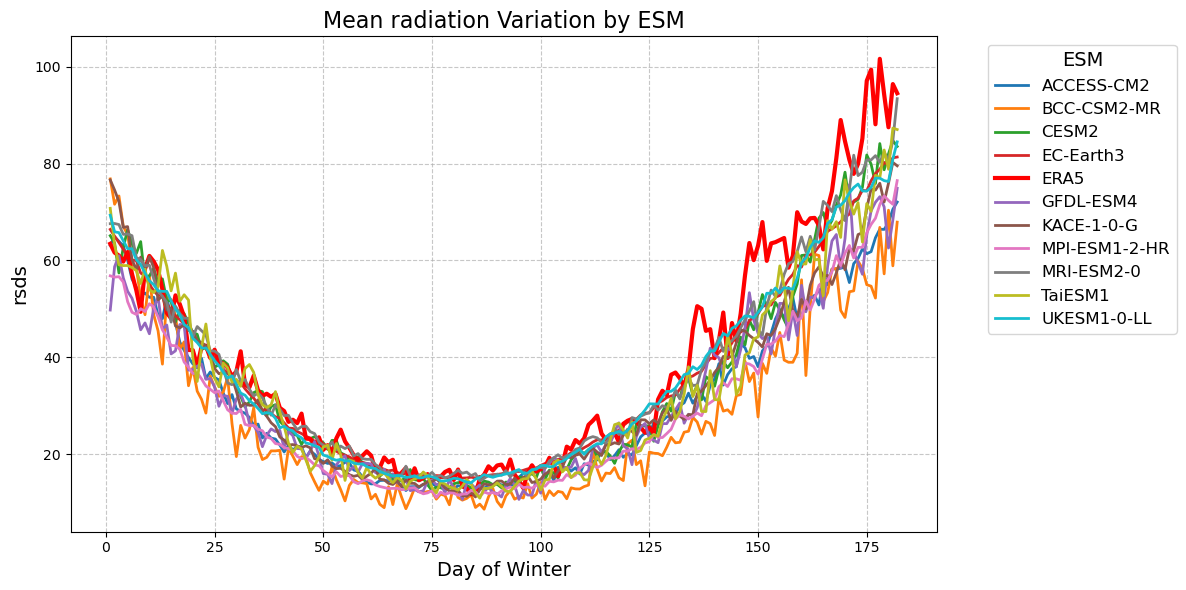

In [13]:
# Plot the data
plt.figure(figsize=(12, 6))
for esm, group in final_df.groupby('ESM'):
    if esm == 'ERA5':
        plt.plot(group['day_of_winter'], group['rsds'], color='red', linewidth=3, label='ERA5')
        continue
    plt.plot(group['day_of_winter'], group['rsds'], label=esm, linewidth=2)
# for esm, group in final_df.groupby('ESM'):
#     plt.plot(group['day_of_winter'], group['rsds'], label=esm, linewidth=2)

# Add title and labels
plt.title('Mean radiation Variation by ESM', fontsize=16)
plt.xlabel('Day of Winter', fontsize=14)
plt.ylabel('rsds', fontsize=14)

# Customize legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title='ESM', title_fontsize=14)

# Add grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()



#### Calculate Bias single plot

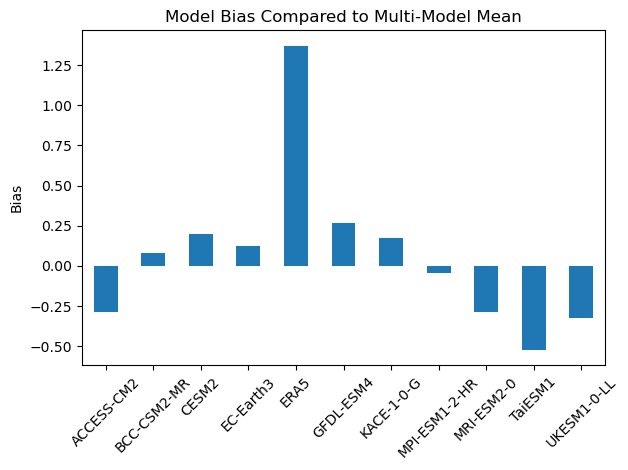

In [14]:
# Calculate bias
mmm = ts_datasets['sfcWind'].groupby('ESM').mean('ESM_run').mean('time')
model_means = ts_datasets['sfcWind'].mean('time').mean()
bias = mmm - model_means

bias.to_series().plot.bar()
plt.title('Model Bias Compared to Multi-Model Mean')
plt.ylabel('Bias')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
